# LSTM

Sequence-based pitch prediction

## Exports and Loading Data

In [74]:
import numpy as np
import pandas as pd
import pickle
import warnings
warnings.filterwarnings('ignore')
 
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
 
print("TensorFlow version:", tf.__version__)

# Load sequence data
print("\nLoading sequence data...")
X_train_seq = np.load('X_train_seq.npy')
X_test_seq = np.load('X_test_seq.npy')
y_train_seq = np.load('y_train_seq.npy')
y_test_seq = np.load('y_test_seq.npy')
 
print(f"X_train_seq shape: {X_train_seq.shape}")
print(f"X_test_seq shape: {X_test_seq.shape}")
print(f"y_train_seq shape: {y_train_seq.shape}")
print(f"y_test_seq shape: {y_test_seq.shape}")
 
# Load metadata
with open('seq_metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)
 
seq_length = metadata['seq_length']
n_features = metadata['n_features']
n_pitch_types = metadata['n_pitch_types']
pitch_encoder = metadata['pitch_encoder']
feature_names = metadata['feature_names']
 
print(f"\nSequence length: {seq_length}")
print(f"Features per pitch: {n_features}")
print(f"Pitch types: {n_pitch_types}")

TensorFlow version: 2.20.0

Loading sequence data...
X_train_seq shape: (160550, 5, 26)
X_test_seq shape: (38056, 5, 26)
y_train_seq shape: (160550,)
y_test_seq shape: (38056,)

Sequence length: 5
Features per pitch: 26
Pitch types: 17


## Baseline Accuracy

In [75]:
unique, counts = np.unique(y_train_seq, return_counts=True)
most_common_idx = unique[np.argmax(counts)]
baseline_accuracy = np.max(counts) / len(y_train_seq)
 
print(f"\nMost common pitch: {pitch_encoder.classes_[most_common_idx]}")
print(f"Baseline accuracy (test): {baseline_accuracy:.1%}")
print(f"\nTARGET: Beat {baseline_accuracy:.1%} accuracy")


Most common pitch: FF
Baseline accuracy (test): 30.6%

TARGET: Beat 30.6% accuracy


## Building LSTM

In [76]:
model = models.Sequential([
    # Input layer
    layers.Input(shape=(seq_length, n_features)),
    
    # First LSTM layer
    layers.LSTM(64, activation='relu', return_sequences=True, dropout=0.2),
    
    # Second LSTM layer
    layers.LSTM(32, activation='relu', dropout=0.2),
    
    # Dense layers for classification
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    
    # Output layer
    layers.Dense(n_pitch_types, activation='softmax'),
])
 
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
 
print("\nModel architecture:")
model.summary()


Model architecture:


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 5, 64)          │        23,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 17)             │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,585 (146.82 KB)

 Trainable params: 37,585 (146.82 KB)

 Non-trainable params: 0 (0.00 B)

## Training

In [77]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
 
print("Training (this may take a minute or two...")
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=30,
    batch_size=512,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)
 
print("\nTraining complete")

Training (this may take a minute or two...
Epoch 1/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.2455 - loss: 2.2658 - val_accuracy: 0.3299 - val_loss: 1.8097
Epoch 2/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3064 - loss: 1.9226 - val_accuracy: 0.3439 - val_loss: 1.7393
Epoch 3/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3214 - loss: 1.8550 - val_accuracy: 0.3501 - val_loss: 1.6938
Epoch 4/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3247 - loss: 1.8132 - val_accuracy: 0.3463 - val_loss: 1.6794
Epoch 5/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3263 - loss: 1.7869 - val_accuracy: 0.3474 - val_loss: 1.6584
Epoch 6/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3314 - loss: 1.7689 - val_accuracy: 0.3512 - val_loss: 1.6539
Epoch 7/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3334 - loss: 1.7535 - val_accuracy: 0.3448 - val_loss: 1.6496
Epoch 8/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accurac

## Evaluation

In [78]:
# Predictions
y_pred_train = model.predict(X_train_seq, verbose=0).argmax(axis=1)
y_pred_test = model.predict(X_test_seq, verbose=0).argmax(axis=1)
 
# Accuracy
train_accuracy = accuracy_score(y_train_seq, y_pred_train)
test_accuracy = accuracy_score(y_test_seq, y_pred_test)
 
print(f"\nAccuracy:")
print(f"  Train: {train_accuracy:.3f} ({train_accuracy:.1%})")
print(f"  Test:  {test_accuracy:.3f} ({test_accuracy:.1%})")
print(f"  Baseline: {baseline_accuracy:.1%}")
print(f"  Improvement over baseline: +{(test_accuracy - baseline_accuracy):.1%}")
 
# Per-pitch accuracy
print(f"\nPer-pitch type accuracy (test set):")
pitch_types = pitch_encoder.classes_
for i, pitch in enumerate(pitch_types):
    mask = y_test_seq == i
    if mask.sum() > 0:
        acc = accuracy_score(y_test_seq[mask], y_pred_test[mask])
        count = mask.sum()
        print(f"  {pitch:3s}: {acc:.1%} ({count:6d} sequences)")


Accuracy:
  Train: 0.352 (35.2%)
  Test:  0.345 (34.5%)
  Baseline: 30.6%
  Improvement over baseline: +3.9%

Per-pitch type accuracy (test set):
  CH : 0.0% (  5167 sequences)
  CU : 0.0% (  1830 sequences)
  EP : 0.0% (     2 sequences)
  FA : 0.0% (     2 sequences)
  FC : 0.1% (  2954 sequences)
  FF : 93.0% ( 11893 sequences)
  FS : 2.9% (   972 sequences)
  KC : 0.0% (  1702 sequences)
  PO : 0.0% (     2 sequences)
  SI : 33.4% (  5787 sequences)
  SL : 1.1% (  4991 sequences)
  ST : 1.2% (  2689 sequences)
  SV : 0.0% (    65 sequences)


## Confusion Matrix


Most common confusions (predicted != actual):
  Actual CH -> Predicted FC:  4264 times ( 82.5%)
  Actual KN -> Predicted FC:  4102 times (  0.0%)
  Actual KC -> Predicted FC:  3808 times (223.7%)
  Actual PO -> Predicted FC:  2230 times (111500.0%)
  Actual FA -> Predicted FC:  2096 times (104800.0%)
  Actual FO -> Predicted FC:  1702 times (  0.0%)
  Actual CS -> Predicted FC:  1539 times (  0.0%)
  Actual CH -> Predicted KC:   903 times ( 17.5%)
  Actual FF -> Predicted FC:   898 times (  7.6%)
  Actual FA -> Predicted KC:   833 times (41650.0%)
  Actual KN -> Predicted KC:   821 times (  0.0%)
  Actual FC -> Predicted KC:   778 times ( 26.3%)
  Actual PO -> Predicted KC:   421 times (21050.0%)
  Actual CS -> Predicted KC:   285 times (  0.0%)
  Actual SI -> Predicted FC:    65 times (  1.1%)

Generating confusion matrix heatmap...
Saved lstm_seq_confusion_matrix.png


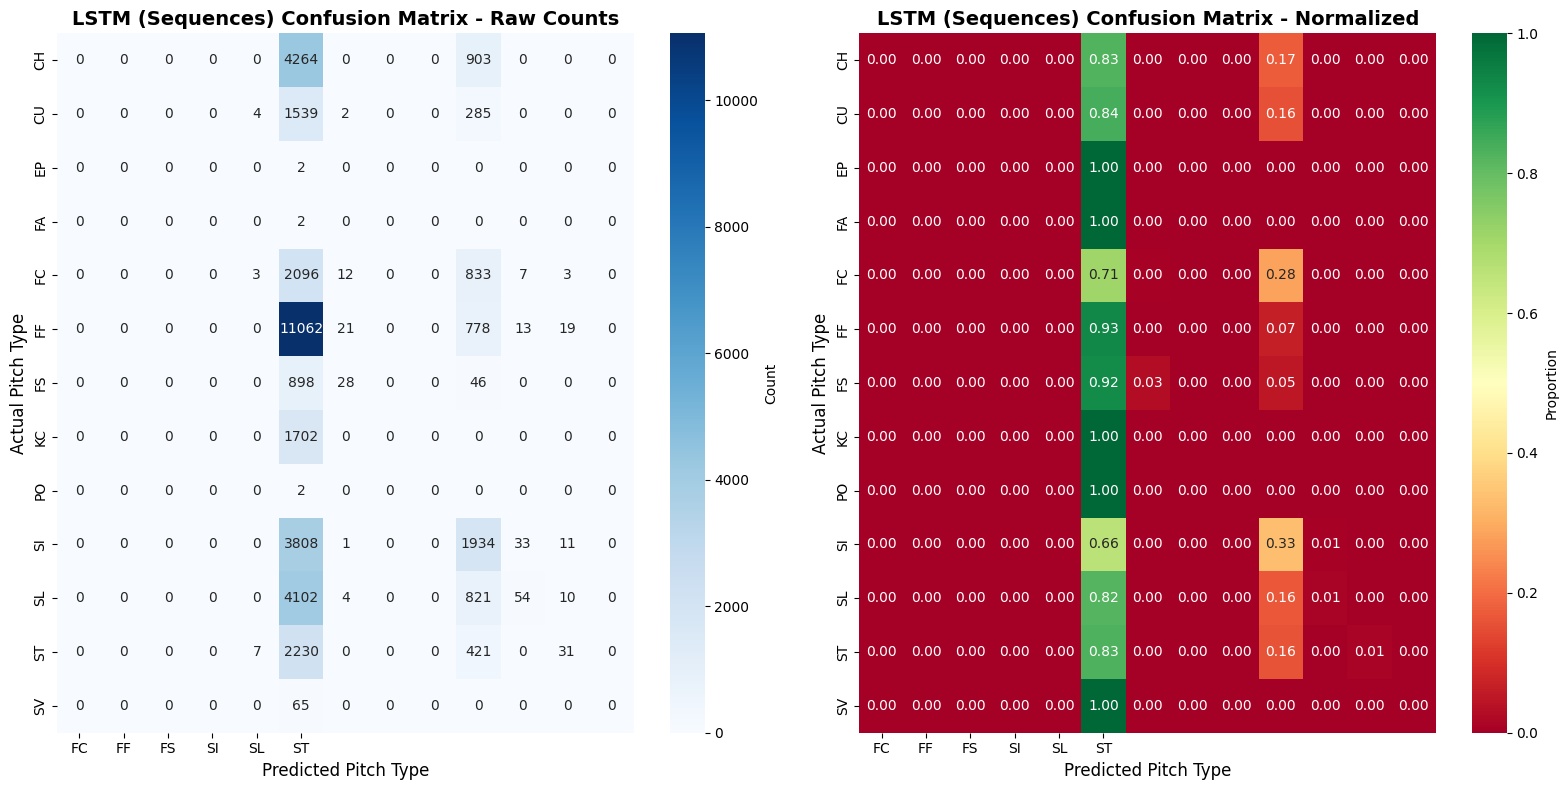

In [79]:
cm = confusion_matrix(y_test_seq, y_pred_test)
 
print("\nMost common confusions (predicted != actual):")
confusions = []
 
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if i != j:
            count = cm[i, j]
            if count > 0:
                actual_pitch = pitch_types[i] if i < len(pitch_types) else f"Unknown_{i}"
                pred_pitch = pitch_types[j] if j < len(pitch_types) else f"Unknown_{j}"
                confusions.append((actual_pitch, pred_pitch, count))
 
confusions.sort(key=lambda x: x[2], reverse=True)
for actual, predicted, count in confusions[:15]:
    actual_idx = np.where(pitch_types == actual)[0]
    if len(actual_idx) > 0:
        total_actual = (y_test_seq == actual_idx[0]).sum()
        pct = count / total_actual * 100 if total_actual > 0 else 0
        print(f"  Actual {actual} -> Predicted {predicted}: {count:5d} times ({pct:5.1f}%)")

# Heatmap visualization
print("\nGenerating confusion matrix heatmap...")

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

actual_pitch_indices = np.unique(y_test_seq)
predicted_pitch_indices = np.unique(y_pred_test)

actual_pitches = pitch_types[actual_pitch_indices]
predicted_pitches = pitch_types[predicted_pitch_indices]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=predicted_pitches, yticklabels=actual_pitches,
            cbar_kws={'label': 'Count'}, ax=ax1)
ax1.set_title('LSTM (Sequences) Confusion Matrix - Raw Counts', fontsize=14, fontweight='bold')
ax1.set_xlabel('Predicted Pitch Type', fontsize=12)
ax1.set_ylabel('Actual Pitch Type', fontsize=12)

sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='RdYlGn', 
            xticklabels=predicted_pitches, yticklabels=actual_pitches,
            cbar_kws={'label': 'Proportion'}, ax=ax2, vmin=0, vmax=1)
ax2.set_title('LSTM (Sequences) Confusion Matrix - Normalized', fontsize=14, fontweight='bold')
ax2.set_xlabel('Predicted Pitch Type', fontsize=12)
ax2.set_ylabel('Actual Pitch Type', fontsize=12)
 
plt.tight_layout()
plt.savefig('lstm_seq_confusion_matrix.png', dpi=300, bbox_inches='tight')
print("Saved lstm_seq_confusion_matrix.png")
plt.show()

## Export

In [80]:
model.save('lstm_seq_model.keras')
print("Saved lstm_seq_model.keras")
 
results_df = pd.DataFrame({
    'actual_pitch_idx': y_test_seq,
    'predicted_pitch_idx': y_pred_test,
    'actual_pitch': [pitch_encoder.classes_[i] for i in y_test_seq],
    'predicted_pitch': [pitch_encoder.classes_[i] for i in y_pred_test],
    'correct': y_test_seq == y_pred_test,
})
results_df.to_csv('lstm_seq_predictions.csv', index=False)
print("Saved lstm_seq_predictions.csv")
 
history_df = pd.DataFrame(history.history)
history_df.to_csv('lstm_seq_training_history.csv', index=False)
print("Saved lstm_seq_training_history.csv")

Saved lstm_seq_model.keras
Saved lstm_seq_predictions.csv
Saved lstm_seq_training_history.csv
